<a href="https://colab.research.google.com/github/sequze/KR_BD_10_00/blob/master/colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Парная регрессия
Модель линейной регрессии строится в виде: $\widehat Y = b_0 + b_1 X$
коэффициены $b_0$ и $b_1$ можно найти следующим образом:

$$b_1 = \frac{\overline{xy} - \bar{x}\bar{y}}{\overline{x^2} - {\bar{x}}^2}, b_0 =  \bar{y} - b_1 \bar{x}, $$
где
$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i, \quad \overline{x^2} = \frac{1}{n}\sum_{i=1}^{n} {x_i}^2, \quad \bar{y} = \frac{1}{n}\sum_{i=1}^{n} y_i, \quad \overline{xy} = \frac{1}{n}\sum_{i=1}^{n} x_i y_i $$

Скачаем файл с данными demad.csv

In [ ]:
!pip install wldhx.yadisk-direct

In [ ]:
!curl -L $(yadisk-direct https://disk.yandex.ru/d/jRi45rI4l2XlpA) -o demand.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100   104  100   104    0     0     67      0  0:00:01  0:00:01 --:--:--   152


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('demand.csv', sep=';')
df

,Q,P
0,96,2.0
1,95,2.3
2,92,4.1
3,94,3.1
4,92,4.0
5,95,2.7
6,93,3.6
7,98,1.0
8,98,1.2
9,97,1.3


In [ ]:
def mnk(X, Y):
  x_ = X.sum() / len(X)
  y_ = Y.sum() / len(Y)
  x2_ = sum(i ** 2 for i in X) / len(X)
  # zip - итератор по набору данных
  xy_ = sum(i * j for i,j in zip(X,Y)) / len(X)

  b_1 = (xy_ - x_ * y_) / (x2_ - x_ * x_)
  b_0 = y_ - b_1 * x_

  return (b_0, b_1)

In [ ]:
(b_0, b_1) = mnk(df['P'], df['Q'])
print(b_0, b_1)

99.94767199666741 -1.953087448328901


Итоговое уравнение: $ Q = 99.95 - 1.95 P + e$

Оценим параметры линейной регрессии с помощью библиотеки _sklearn_

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [ ]:
model = LinearRegression()
lst = [[df['P'][i]] for i in range(len(df['P']))]
#print(lst)
#print(df['P'])
model.fit(lst,df['Q'])
print(model. intercept_ , model. coef_ , model. score (lst,df['Q']))


99.94767199666741 [-1.95308745] 0.9862525267244945


С сайта finam.ru скачайте цены закрытия какого-нибудь финансового инструмента (не менее 500 наблюдений). Методом наименьших квадратов постройте линию тренда, откладывая по оси OX номер момента времени, по оси OY — цену закрытия

## Линия тренда для цен закрытия акций Роснефти

Источник данных: [экспорт котировок Роснефти на Finam](https://www.finam.ru/quote/moex/rosn/export/).  
Периодичность — **1 день**, период в исходной выгрузке — **12.07.2024–14.09.2026**. После обработки осталось 675 наблюдений и два столбца: порядковый номер момента времени `NUMBER` и цена закрытия `CLOSE`.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

data_url = 'rosneft_close.csv'
rosn = pd.read_csv(data_url, sep=';')

assert list(rosn.columns) == ['NUMBER', 'CLOSE']
assert len(rosn) >= 500

In [ ]:
X = rosn[['NUMBER']]
Y = rosn['CLOSE']

model = LinearRegression().fit(X, Y)
rosn['TREND'] = model.predict(X)
r_squared = model.score(X, Y)

print(f'CLOSE = {model.intercept_:.4f} {model.coef_[0]:+.6f} · NUMBER; R² = {r_squared:.4f}')

CLOSE = 525.8448 -0.259416 · NUMBER; R² = 0.6136


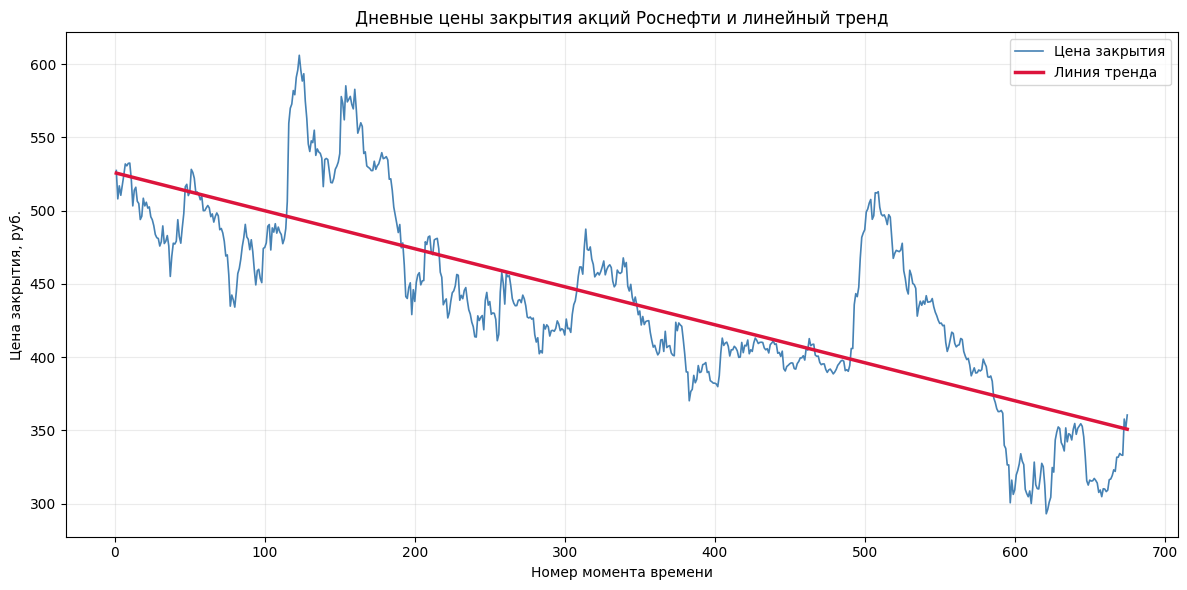

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(rosn['NUMBER'], rosn['CLOSE'], color='steelblue', linewidth=1.2, label='Цена закрытия')
plt.plot(rosn['NUMBER'], rosn['TREND'], color='crimson', linewidth=2.5, label='Линия тренда')
plt.xlabel('Номер момента времени')
plt.ylabel('Цена закрытия, руб.')
plt.title('Дневные цены закрытия акций Роснефти и линейный тренд')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## Однослойный персептрон


In [ ]:
import numpy as np

rosn['CLASS'] = (rosn['CLOSE'] > rosn['TREND']).astype(int)

X = rosn[['TREND', 'CLOSE']].to_numpy()
target = rosn['CLASS'].to_numpy()

In [ ]:
class Perceptron:
    def __init__(self, input_count):
        self.x = np.zeros(input_count)
        self.y = 0
        self.w = np.random.random(input_count) * 0.2 + 0.1

    def cy(self, x):
        self.x = x
        self.y = 0

        for i in range(len(self.x)):
            self.y += self.x[i] * self.w[i]

        self.y = 1 if self.y > 0.5 else 0
        return self.y

    def study(self, X, target, epochs):
        for _ in range(epochs):
            for x, label in zip(X, target):
                prediction = self.cy(x)
                error = label - prediction

                for i in range(len(self.x)):
                    self.w[i] += 0.1 * error * self.x[i]

In [ ]:
np.random.seed(42)

epochs = 100
perceptron = Perceptron(input_count=2)
perceptron.study(X, target, epochs)

predictions = np.array([perceptron.cy(x) for x in X])
accuracy = (predictions == target).mean()

print(f'Количество эпох: {epochs}')
print(f'Точность: {accuracy:.2%}')

Количество эпох: 100
Точность: 100.00%


## 2. Обучение по правилу Хэбба


In [ ]:
class HebbPerceptron:
    def __init__(self):
        self.w = 0

    def cy(self, x):
        return 1 if self.w * x > 0 else 0

    def study(self, X, target, epochs):
        # приводим классы к {-1, 1}
        bipolar_target = np.where(target == 1, 1, -1)

        for _ in range(epochs):
            for x, label in zip(X, bipolar_target):
                self.w += 0.1 * label * x


hebb_X = (rosn['CLOSE'] - rosn['TREND']).to_numpy()
hebb_target = rosn['CLASS'].to_numpy()

hebb_perceptron = HebbPerceptron()
hebb_perceptron.study(hebb_X, hebb_target, epochs=100)

hebb_predictions = np.array([hebb_perceptron.cy(x) for x in hebb_X])
hebb_accuracy = (hebb_predictions == hebb_target).mean()

print(f'Точность обучения по правилу Хэбба: {hebb_accuracy:.2%}')

Точность обучения по правилу Хэбба: 100.00%


## 3. Классификация данных из vk_perc.csv

Задача классификации: по количеству друзей, подписчиков, фотографий и видеозаписей определить, относится ли пользователь к категории `kmeans = 0`.

- класс 1 — значение первого столбца равно 0;
- класс 0 — значение первого столбца не равно 0.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

vk_url = 'vk_perc.csv'
vk = pd.read_csv(vk_url, sep=';')

X_vk = vk.iloc[:, 1:].to_numpy()
target_vk = (vk.iloc[:, 0] == 0).astype(int).to_numpy()

np.random.seed(42)
vk_perceptron = Perceptron(input_count=X_vk.shape[1])
vk_perceptron.study(X_vk, target_vk, epochs=100)

vk_predictions = np.array([vk_perceptron.cy(x) for x in X_vk])

print(f'Accuracy:  {accuracy_score(target_vk, vk_predictions):.4f}')
print(f'Precision: {precision_score(target_vk, vk_predictions, zero_division=0):.4f}')
print(f'Recall:    {recall_score(target_vk, vk_predictions, zero_division=0):.4f}')
print(f'F1-score:  {f1_score(target_vk, vk_predictions, zero_division=0):.4f}')

Accuracy:  0.6833
Precision: 0.6870
Recall:    0.9753
F1-score:  0.8061


Персептрон получил точность **68.33%**. Для категории `kmeans = 0` полнота составила **97.53%**, а точность положительных предсказаний — **68.70%**. Значение F1-меры равно **80.61%**.